<a href="https://colab.research.google.com/github/Perfectto1/html-portfolio/blob/main/MLProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# ================================
# 🔹 Import Libraries
# ================================
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [14]:
# 🔹 Create Dataset
# ================================
data = pd.DataFrame({
    'study_hours': [2, 3, 4, 5, 6, 7, 8, 1, 2.5, 3.5, 6.5, 7.5],
    'attendance': [60, 65, 70, 75, 80, 85, 90, 55, 68, 72, 88, 92],
    'assignments': [50, 55, 60, 65, 70, 75, 80, 45, 58, 62, 78, 82],
    'final_marks': [52, 56, 61, 66, 72, 78, 85, 48, 59, 64, 80, 87]
})

In [15]:
# 🔹 Feature Engineering
# ================================
data['merit'] = data['final_marks'].apply(lambda x: 1 if x >= 70 else 0)

print("Dataset:\n", data)


Dataset:
     study_hours  attendance  assignments  final_marks  merit
0           2.0          60           50           52      0
1           3.0          65           55           56      0
2           4.0          70           60           61      0
3           5.0          75           65           66      0
4           6.0          80           70           72      1
5           7.0          85           75           78      1
6           8.0          90           80           85      1
7           1.0          55           45           48      0
8           2.5          68           58           59      0
9           3.5          72           62           64      0
10          6.5          88           78           80      1
11          7.5          92           82           87      1



Correlation Matrix:

             study_hours  attendance  assignments  final_marks     merit
study_hours     1.000000    0.979010     0.979010     0.977979  0.884377
attendance      0.979010    1.000000     1.000000     0.995826  0.873951
assignments     0.979010    1.000000     1.000000     0.995826  0.873951
final_marks     0.977979    0.995826     0.995826     1.000000  0.888298
merit           0.884377    0.873951     0.873951     0.888298  1.000000


<Axes: >

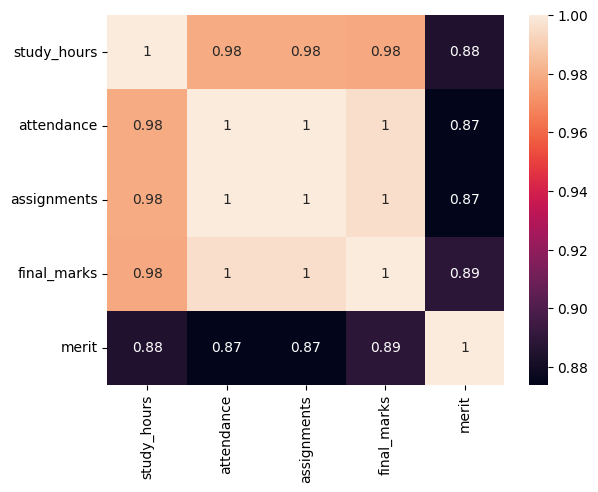

In [16]:
# 🔹 Correlation Analysis
# ================================
print("\nCorrelation Matrix:\n")
corr_matrix = data.corr()
print(corr_matrix)

# Heatmap
sns.heatmap(corr_matrix, annot=True)


In [17]:
# 🔹 MANUAL REGRESSION MODEL
# ================================

# Extract correlation with target
corr = corr_matrix['final_marks']

w1 = corr['study_hours']
w2 = corr['attendance']
w3 = corr['assignments']

# Normalize weights
total = abs(w1) + abs(w2) + abs(w3)
w1, w2, w3 = w1/total, w2/total, w3/total

print("\nWeights:")
print("Study Hours:", w1)
print("Attendance:", w2)
print("Assignments:", w3)

# Prediction function (Marks)
def predict_marks(study_hours, attendance, assignments):
    return (w1 * study_hours * 10 +
            w2 * attendance +
            w3 * assignments)



Weights:
Study Hours: 0.32932678677957994
Attendance: 0.33533660661021003
Assignments: 0.33533660661021003


In [18]:
# 🔹 LOGISTIC REGRESSION MODEL
# ================================

# Features & Target
X = data[['study_hours', 'attendance', 'assignments']]
y = data['merit']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nClassification Accuracy:", accuracy)



Classification Accuracy: 1.0


In [19]:
# 🔹 TEST WITH NEW STUDENT
# ================================

study_hours = 5
attendance = 78
assignments = 70

# Predict Marks (Manual Model)
pred_marks = predict_marks(study_hours, attendance, assignments)

# Predict Merit (Logistic Regression)
new_data = np.array([[study_hours, attendance, assignments]])
pred_merit = model.predict(new_data)

print("\n--- New Student Prediction ---")
print("Predicted Final Marks:", pred_marks)
print("Predicted Merit (1=Yes, 0=No):", pred_merit[0])


--- New Student Prediction ---
Predicted Final Marks: 66.09615711729009
Predicted Merit (1=Yes, 0=No): 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [20]:
# 🔹 REGRESSION EVALUATION (MSE)
# ================================

predictions = []

for i in range(len(data)):
    pm = predict_marks(
        data['study_hours'][i],
        data['attendance'][i],
        data['assignments'][i]
    )
    predictions.append(pm)

data['predicted_marks'] = predictions

mse = np.mean((data['final_marks'] - data['predicted_marks'])**2)

print("\nMean Squared Error (Regression):", mse)


Mean Squared Error (Regression): 34.8650530018133
